|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 1:</h2>|<h1>The Naive Loop<h1>|
|<h2>Section:</h2>|<h1>The roofline<h1>|
|<h2>Lecture:</h2>|<h1><b>The roofline, measured: watch a matmul cross the ridge<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# find the repo root. The directory you start from does not matter.
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import time
import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# Watch a matmul move between two machines

You have one weight matrix and one batch knob. A small batch makes a memory
problem. A large batch makes the same code, on the same data, into a compute
problem.

The knee must land at the ridge point that you measured.

In [2]:
bandwidth = cudalib.peak_bandwidth(fresh=True)
print(f'bandwidth: {bandwidth:.0f} GB/s')

K = 8192                            # weights are K*K*2 bytes
W = torch.randn(K, K, dtype=torch.bfloat16, device='cuda')
print(f'weights:   {K*K*2/1e6:.0f} MB')
print(f'L2:        {torch.cuda.get_device_properties(0).L2_cache_size/1e6:.0f} MB')
print('\nThe weights have to be bigger than L2, or you measure the cache.')

bandwidth: 378 GB/s
weights:   134 MB
L2:        50 MB

The weights have to be bigger than L2, or you measure the cache.


### Arithmetic intensity

For `x @ W` with a batch of B:

$$\text{FLOP} = 2BK^2 \qquad \text{bytes} = \underbrace{2K^2}_{\text{weights}} + \underbrace{4BK}_{\text{in and out}}$$

The weights term does not move. So the intensity climbs with B, and it climbs
to B. The first notebook predicted exactly this.

In [3]:
batches = [1,2,4,8,16,32,64,128,256,512,1024,2048]
rows = []

for B in batches:
  x  = torch.randn(B, K, dtype=torch.bfloat16, device='cuda')
  ms = cudalib.bench_ms(lambda: x@W, iters=30, best_of=3)
  flop  = 2*B*K*K
  bytes_= K*K*2 + B*K*2*2
  rows.append((B, flop/bytes_, flop/(ms*1e-3), bytes_/(ms*1e-3)))

print(f"{'batch':>6} {'intensity':>10} {'TFLOP/s':>9} {'GB/s':>8}")
for B,ai,fl,by in rows:
  print(f'{B:>6} {ai:>10.1f} {fl/1e12:>9.1f} {by/1e9:>8.0f}')

 batch  intensity   TFLOP/s     GB/s
     1        1.0       0.4      415
     2        2.0       0.8      414
     4        4.0       1.7      415
     8        8.0       3.3      415
    16       15.9       6.6      415
    32       31.8      12.1      380
    64       63.0      26.0      413
   128      124.1      50.5      407
   256      240.9      62.1      258
   512      455.1      65.9      145
  1024      819.2      68.1       83
  2048     1365.3      63.1       46


# The roofline

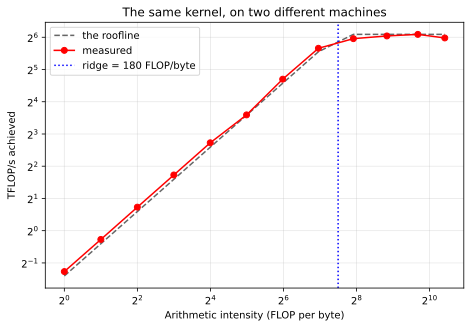

In [4]:
ai   = np.array([r[1] for r in rows])
tfl  = np.array([r[2] for r in rows])/1e12
peak_c = tfl.max()

roof = np.minimum(ai * bandwidth/1e3, peak_c)     # GB/s * FLOP/byte -> TFLOP/s
ridge = peak_c*1e3 / bandwidth

plt.figure(figsize=(7.5,4.8))
plt.plot(ai, roof, 'k--', alpha=.6, label='the roofline')
plt.plot(ai, tfl,  'ro-',           label='measured')
plt.axvline(ridge, color='b', ls=':', label=f'ridge = {ridge:.0f} FLOP/byte')
plt.xscale('log', base=2); plt.yscale('log', base=2)
plt.xlabel('Arithmetic intensity (FLOP per byte)')
plt.ylabel('TFLOP/s achieved')
plt.title('The same kernel, on two different machines')
plt.legend(); plt.grid(alpha=.3); plt.show()

In [5]:
lo = max(b for b,a,f,g in rows if a < ridge)
hi = min(b for b,a,f,g in rows if a > ridge)
print(f'predicted ridge:      {ridge:.0f} FLOP/byte')
print(f'measured knee sits between batch {lo} and batch {hi}')
print(f'   which is intensity {[a for b,a,f,g in rows if b==lo][0]:.0f} .. {[a for b,a,f,g in rows if b==hi][0]:.0f}')

predicted ridge:      180 FLOP/byte
measured knee sits between batch 128 and batch 256
   which is intensity 124 .. 241


### Two rows in that table deserve an argument

**The GB/s column passes the measured bandwidth.** That looks impossible.

The explanation is the measurement itself. A copy reads and writes. This test
almost only reads. A read-only stream beats a copy on most cards.

So the number is correct and the comparison is loose. You must know which.

**The left half of the plot is flat in TFLOP/s, but the roofline is a slope.**
Look again. On the left the red points climb with intensity, exactly like the
roofline.

The flat quantity over there is GB/s. On the left the card does the only thing
it can do. It reads the weights as fast as the memory permits.

That is all of decode. Every decode step in this course is a point on the left
half of this plot. Every technique in the course moves the point right.